In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1) Environment initialized: pandas, numpy, matplotlib, KMeans


In [2]:
# 2) Load dataset from the given URL
url = "https://raw.githubusercontent.com/satishgunjal/datasets/master/Mall_Customers.csv"
df = pd.read_csv(url)

# Check dimensions and preview first rows
print("Shape:", df.shape)
df.head()


Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# 3) Exploration: descriptive statistics + nulls/info
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
# Optional: explicit null-check (helpful for the report)
df.isnull().sum()


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
# 4) Rename columns for easier manipulation
df = df.rename(columns={
    "Annual Income (k$)": "AnnualIncome",
    "Spending Score (1-100)": "SpendingScore"
})

print(df.columns)
df.head()


Index(['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore'], dtype='str')


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


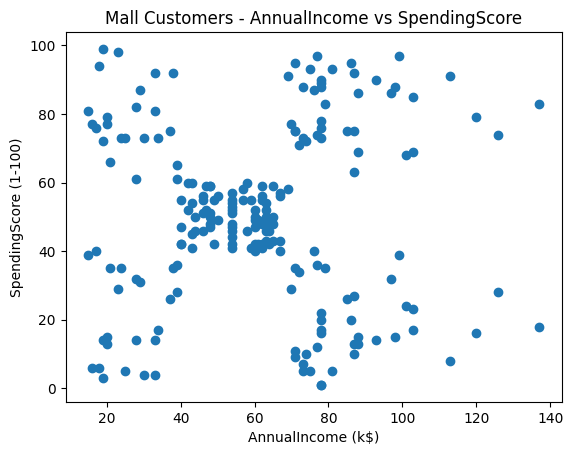

In [7]:
# 5) First visualization: scatter plot (AnnualIncome vs SpendingScore)
plt.figure()
plt.scatter(df["AnnualIncome"], df["SpendingScore"])
plt.title("Mall Customers - AnnualIncome vs SpendingScore")
plt.xlabel("AnnualIncome (k$)")
plt.ylabel("SpendingScore (1-100)")
plt.show()


In [8]:
# 6) Build feature matrix X from AnnualIncome and SpendingScore
X = df.loc[:, ["AnnualIncome", "SpendingScore"]].values

# Verify first rows
print("First 5 rows of X:\n", X[:5])


First 5 rows of X:
 [[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]


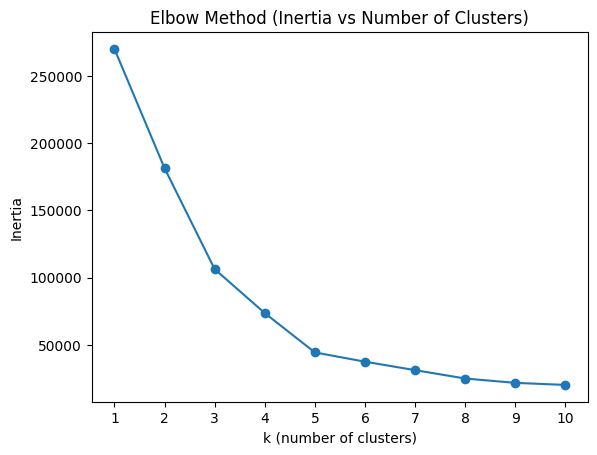

In [9]:
# 7) Elbow method: k=1..10, random init, random_state=42, store inertia
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init="random", random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

# Plot inertia vs k
plt.figure()
plt.plot(list(K_range), inertias, marker="o")
plt.title("Elbow Method (Inertia vs Number of Clusters)")
plt.xlabel("k (number of clusters)")
plt.ylabel("Inertia")
plt.xticks(list(K_range))
plt.show()


In [10]:
# 8) Train KMeans with k=5 (random_state=42) and get predicted labels
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, init="random", random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print("Unique cluster labels:", np.unique(labels))


Unique cluster labels: [0 1 2 3 4]


In [11]:
# 9) Add labels as a new column 'Cluster' and analyze segments
df["Cluster"] = labels

# Counts per cluster
print("Counts per cluster:")
print(df["Cluster"].value_counts().sort_index())

# Mean income and spending per cluster
segment_summary = df.groupby("Cluster")[["AnnualIncome", "SpendingScore"]].mean()
print("\nMean AnnualIncome and SpendingScore per cluster:")
print(segment_summary)

# (Optional) A richer summary including size + std
df.groupby("Cluster")[["AnnualIncome", "SpendingScore"]].agg(["count", "mean", "std"])


Counts per cluster:
Cluster
0    23
1    22
2    35
3    39
4    81
Name: count, dtype: int64

Mean AnnualIncome and SpendingScore per cluster:
         AnnualIncome  SpendingScore
Cluster                             
0           26.304348      20.913043
1           25.727273      79.363636
2           88.200000      17.114286
3           86.538462      82.128205
4           55.296296      49.518519


AnnualIncome                       SpendingScore                      
               count       mean        std         count       mean        std
Cluster                                                                       
0                 23  26.304348   7.893811            23  20.913043  13.017167
1                 22  25.727273   7.566731            22  79.363636  10.504174
2                 35  88.200000  16.399067            35  17.114286   9.952154
3                 39  86.538462  16.312485            39  82.128205   9.364489
4                 81  55.296296   8.988109            81  49.518519   6.530909

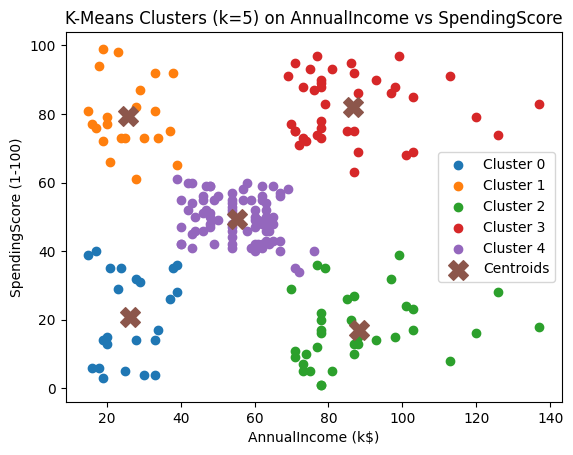

In [12]:
# 10) Visualize clusters on (AnnualIncome, SpendingScore) with one color per segment
plt.figure()

# Plot each cluster separately
for c in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == c]
    plt.scatter(cluster_data["AnnualIncome"], cluster_data["SpendingScore"], label=f"Cluster {c}")

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], marker="X", s=200, label="Centroids")

plt.title("K-Means Clusters (k=5) on AnnualIncome vs SpendingScore")
plt.xlabel("AnnualIncome (k$)")
plt.ylabel("SpendingScore (1-100)")
plt.legend()
plt.show()
